# CopyKAT CNV analysis

CopyKAT was run per sample in a separate environment.


In [ ]:
import os
from pathlib import Path

import infercnvpy as cnv
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False)


In [ ]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SOURCE_DATA_ROOT = Path(
    os.environ.get("EPEN_SOURCE_DATA", REPO_ROOT.parent / "analysis" / "anndata")
).expanduser().resolve()
OUTPUT_ROOT = Path(
    os.environ.get("EPEN_OUTPUT_DIR", REPO_ROOT / "outputs")
).expanduser().resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCRIPTS_DIR = REPO_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

def prefer_checkpoint(local_name, source_path):
    local_path = OUTPUT_ROOT / local_name
    return local_path if local_path.exists() else SOURCE_DATA_ROOT / source_path


In [ ]:
CLUSTERED_SOURCE = "2000HVG_rg_cc_mt/clustered_niter.h5ad"
SOURCE_MERGED_CHECKPOINT = SOURCE_DATA_ROOT / "2000HVG_rg_cc_mt/clustered_niter_with_cnv_cpkat.h5ad"
COPYKAT_MERGED_SOURCE = "2000HVG_rg_cc_mt/clustered_niter_with_cnv_cpkat.h5ad"

local_copykat_root = OUTPUT_ROOT / "copykat_per_sample"
source_copykat_root = SOURCE_DATA_ROOT / "2000HVG_rg_cc_mt/copykat_per_sample"
COPYKAT_RESULTS_ROOT = Path(
    os.environ.get(
        "EPEN_COPYKAT_RESULTS",
        local_copykat_root if local_copykat_root.exists() else source_copykat_root,
    )
).expanduser().resolve()


## Run CopyKAT per sample

```bash
python scripts/06_copykat.py \
  --input outputs/04_clustered.h5ad \
  --output-dir outputs/copykat_per_sample \
  --threads 8
```


## Merge per-sample CopyKAT results


In [ ]:
adata2 = sc.read_h5ad(prefer_checkpoint(
    "04_clustered.h5ad", CLUSTERED_SOURCE
))

prediction_files = sorted(COPYKAT_RESULTS_ROOT.glob("*/*_copykat_copykat_prediction.txt"))
if not prediction_files:
    raise FileNotFoundError(f"No CopyKAT prediction files under {COPYKAT_RESULTS_ROOT}")

pred = pd.concat(
    pd.read_csv(path, sep="\t", usecols=["cell.names", "copykat.pred"])
    .set_index("cell.names")["copykat.pred"]
    for path in prediction_files
)
pred = pred[~pred.index.duplicated(keep="first")]
adata2.obs["copykat_pred"] = pred.reindex(adata2.obs_names)


In [ ]:
sample_col = "sample"
suffix = "_copykat_copykat_CNA_results.txt"
meta_cols = ["chrom", "chrompos", "abspos"]

template = None
for sample_id in adata2.obs[sample_col].astype(str).unique():
    path = COPYKAT_RESULTS_ROOT / sample_id / f"{sample_id}{suffix}"
    if path.exists():
        frame = pd.read_csv(path, sep="\t")
        template = frame[meta_cols].copy()
        n_bins = frame.shape[0]
        break
if template is None:
    raise FileNotFoundError("No CopyKAT CNA result file found")

matrix = np.full((adata2.n_obs, n_bins), np.nan, dtype=np.float32)
obs_index = pd.Index(adata2.obs_names)
obs_with_sample = pd.Index(
    adata2.obs_names + "_" + adata2.obs[sample_col].astype(str) + "_cellbender_filter"
)
failed = []

for sample_id in adata2.obs[sample_col].astype(str).unique():
    path = COPYKAT_RESULTS_ROOT / sample_id / f"{sample_id}{suffix}"
    if not path.exists():
        failed.append((sample_id, "missing_file"))
        continue
    frame = pd.read_csv(path, sep="\t")
    if frame.shape[0] != n_bins:
        failed.append((sample_id, f"bin_mismatch:{frame.shape[0]}"))
        continue
    frame = frame.rename(columns=lambda value: value.replace(".1_", "-1_", 1))
    cell_columns = [column for column in frame.columns if column not in meta_cols]
    values = frame[cell_columns].to_numpy(dtype=np.float32).T
    indexer = obs_index.get_indexer(cell_columns)
    matched = indexer >= 0
    if not matched.any():
        indexer = obs_with_sample.get_indexer(cell_columns)
        matched = indexer >= 0
    if not matched.any():
        failed.append((sample_id, "no_cells_matched"))
        continue
    matrix[indexer[matched], :] = values[matched, :]

adata2.obsm["X_cnv_cpkat"] = matrix

# Copy plotting metadata from the merged checkpoint when needed.
if "cnv_cpkat" not in adata2.uns and SOURCE_MERGED_CHECKPOINT.exists():
    metadata_source = sc.read_h5ad(SOURCE_MERGED_CHECKPOINT, backed="r")
    adata2.uns["cnv_cpkat"] = dict(metadata_source.uns["cnv_cpkat"])
    metadata_source.file.close()

adata2.write_h5ad(OUTPUT_ROOT / "05_copykat_merged.h5ad", compression="gzip")
failed[:10]


### Load CopyKAT-merged data


In [ ]:
adata = sc.read_h5ad(prefer_checkpoint(
    "05_copykat_merged.h5ad", COPYKAT_MERGED_SOURCE
))
adata


## Filter undefined calls and downsample for visualization


In [ ]:
# filter out low-conf / undefined copykat labels
pred = adata.obs["copykat_pred"]
pred_str = pred.astype(str).str.lower()

drop_vals = {"na", "nan", "not.defined"}
mask = pred.notna() & ~pred_str.str.startswith(("c1", "c2")) & ~pred_str.isin(drop_vals)

adata = adata[mask].copy()

# optional: clean categories
# if hasattr(adata2.obs["copykat_pred"], "cat"):
#     adata2.obs["copykat_pred"] = adata2.obs["copykat_pred"].cat.remove_unused_categories()


In [ ]:
import numpy as np

sample_col = "sample"
pred_col = "copykat_pred"
frac = 0.10
rng = np.random.default_rng(0)

obs = adata.obs[[sample_col, pred_col]].copy()
keep = []

for sample, sub in obs.groupby(sample_col):
    n_total = len(sub)
    if n_total == 0:
        continue

    n_target = int(np.ceil(n_total * frac))

    sub_aneu = sub[sub[pred_col] == "aneuploid"]
    sub_dip = sub[sub[pred_col] == "diploid"]

    if len(sub_aneu) > 0 and len(sub_dip) > 0:
        if n_target < 2 and n_total >= 2:
            n_target = 2  # enforce both types when possible

        pick = []
        pick.extend(rng.choice(sub_aneu.index, size=1, replace=False))
        pick.extend(rng.choice(sub_dip.index, size=1, replace=False))

        remaining = n_target - len(pick)
        if remaining > 0:
            rest = sub.drop(pick)
            pick.extend(rng.choice(rest.index, size=remaining, replace=False))
    else:
        pick = rng.choice(sub.index, size=min(n_target, n_total), replace=False)

    keep.extend(pick)

adata_sub = adata[keep].copy()


/tmp/ipykernel_77820/3177290780.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sample, sub in obs.groupby(sample_col):


## CopyKAT chromosome heatmap


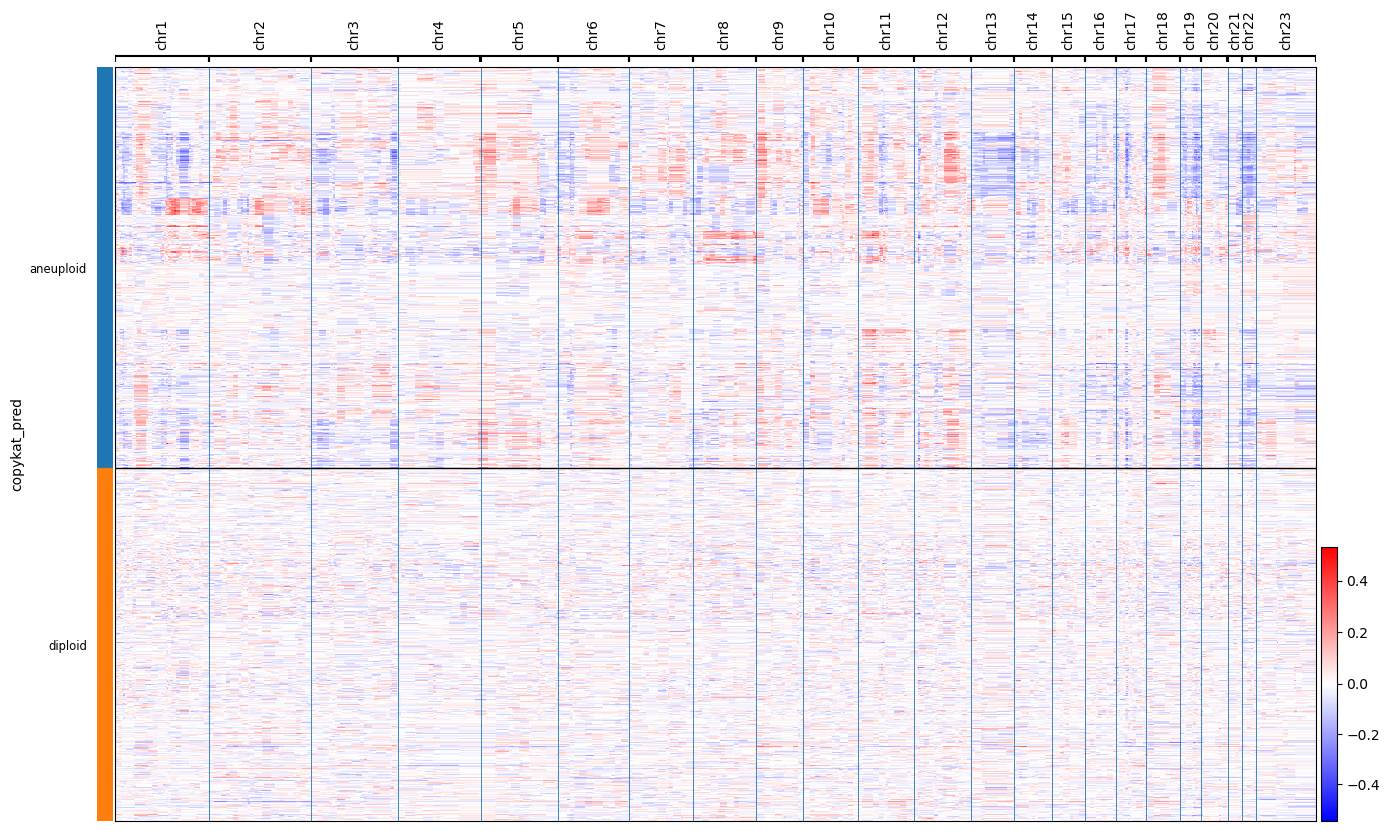

In [ ]:
cnv.pl.chromosome_heatmap(adata_sub, groupby="copykat_pred",use_rep="cnv_cpkat",dendrogram = False)